In [2]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 42.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 46.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score
import shap

/Users/sofieappel/Downloads/Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df = pd.read_csv('fires_target')

df = pd.DataFrame(df)
df.head()

,Unnamed: 0,lat,lon,year,month,temp_month,precip_month,gisacres,fires_target
0,0,39.262110,-108.705537,2005,7,80.060176,0.001951,17.511509,0
1,1,39.246299,-108.700311,2017,5,61.228730,0.035027,0.707301,0
2,2,39.261301,-108.714669,2016,7,78.095381,0.015024,0.123598,0
3,3,40.748563,-107.756655,2015,9,61.494160,0.027260,7.225905,0
4,4,39.208467,-108.654979,2017,5,61.228730,0.035027,28.773811,0


In [11]:
features = ['lat','lon','year','month','temp_month','precip_month']
target = 'fires_target'

In [13]:
#Check for multicollinearity
corr = df[features].corr()
corr

,lat,lon,year,month,temp_month,precip_month
lat,1.000000,-0.169335,0.035282,-0.043938,0.062057,-0.204049
lon,-0.169335,1.000000,0.126582,-0.038008,-0.269913,0.274776
year,0.035282,0.126582,1.000000,0.138557,0.200201,0.070491
month,-0.043938,-0.038008,0.138557,1.000000,0.159359,0.046121
temp_month,0.062057,-0.269913,0.200201,0.159359,1.000000,-0.297729
precip_month,-0.204049,0.274776,0.070491,0.046121,-0.297729,1.000000


No significantly strong collinear relationships.

In [14]:
display(df[features].head())

display(df[[target]].head())

,lat,lon,year,month,temp_month,precip_month
0,39.262110,-108.705537,2005,7,80.060176,0.001951
1,39.246299,-108.700311,2017,5,61.228730,0.035027
2,39.261301,-108.714669,2016,7,78.095381,0.015024
3,40.748563,-107.756655,2015,9,61.494160,0.027260
4,39.208467,-108.654979,2017,5,61.228730,0.035027


,fires_target
0,0
1,0
2,0
3,0
4,0


In [15]:
#80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size = 0.2, random_state = 0)

In [16]:
# No. of instance with 1 in target variable for training set
display(y_train.value_counts())

# No. of instance with 1 in target variable for test set
display(y_test.value_counts())

fires_target
0    568
1    189
Name: count, dtype: int64

fires_target
0    142
1     48
Name: count, dtype: int64

In [17]:
# Scaling the features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

In [18]:
display(pd.DataFrame(X_train).head())

,0,1,2,3,4,5
0,0.645728,-0.471664,1.048394,-0.043321,0.929197,-0.474483
1,-2.091026,-0.435385,-0.489657,-0.043321,0.680512,0.707793
2,0.752565,-0.535118,-1.344130,-0.505207,0.718777,-0.834490
3,-0.890556,1.059867,-1.685919,2.266112,-2.912611,-0.210233
4,-0.010310,-0.243734,-0.318762,-0.043321,0.522645,-0.698840


In [19]:
# Model building
classifier_linear = SVC(kernel='linear')
classifier_poly = SVC(kernel = 'poly')
classifier_rbf = SVC(kernel = 'rbf')

# Fitting the model
classifier_linear.fit(X_train, y_train)
classifier_poly.fit(X_train, y_train)
classifier_rbf.fit(X_train, y_train)

# Predicting the Test set results
pred_linear = classifier_linear.predict(sc.transform(X_test))
pred_poly = classifier_poly.predict(sc.transform(X_test))
pred_rbf = classifier_rbf.predict(sc.transform(X_test))

Text(0.5, 1.0, 'Confusion Matrix for Simple SVM with RBF Kernel')

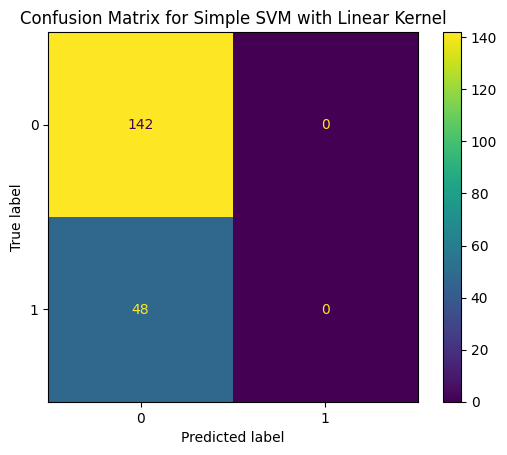

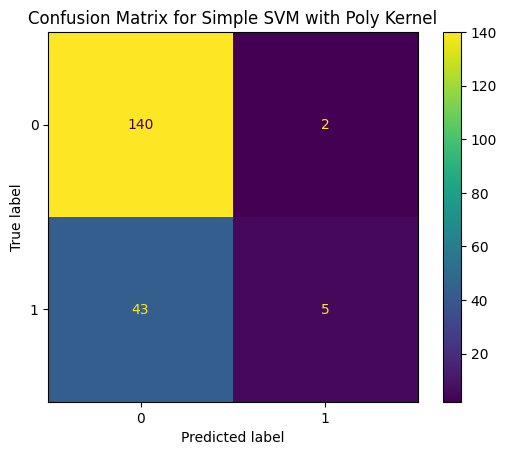

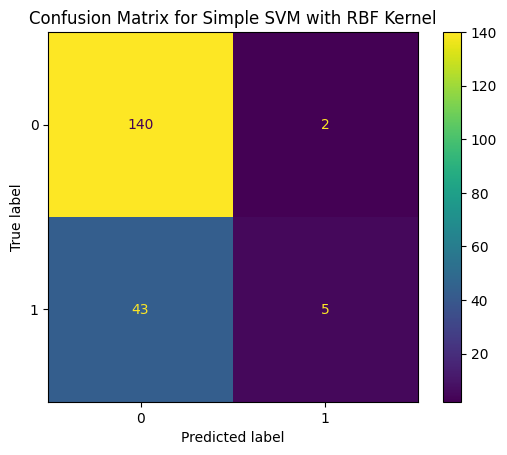

In [20]:
# Generating the confusion matrix for the linear kernel
cm_linear = confusion_matrix(y_test, pred_linear)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=classifier_linear.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Simple SVM with Linear Kernel')

# Generating the confusion matrix for the poly kernel
cm_poly = confusion_matrix(y_test, pred_poly)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=classifier_poly.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Simple SVM with Poly Kernel')

# Generating the confusion matrix for the RBF kernel
cm_rbf = confusion_matrix(y_test, pred_rbf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=classifier_rbf.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Simple SVM with RBF Kernel')

In [21]:
# Calculating the accuracy, f1 score and recall for all the kernels
accuracy_linear = accuracy_score(y_test, pred_linear)
f1_linear = f1_score(y_test, pred_linear)
recall_linear = recall_score(y_test, pred_linear)
accuracy_poly = accuracy_score(y_test, pred_poly)
f1_poly = f1_score(y_test, pred_poly)
recall_poly = recall_score(y_test, pred_poly)
accuracy_rbf = accuracy_score(y_test, pred_rbf)
f1_rbf = f1_score(y_test, pred_rbf)
recall_rbf= recall_score(y_test, pred_rbf)


# Adding the scores to a dataframe
scores = pd.DataFrame({'Kernel': ['Linear', 'Poly', 'RBF']})
scores['Accuracy'] = [accuracy_linear, accuracy_poly, accuracy_rbf]
scores['F1 Score'] = [f1_linear, f1_poly, f1_rbf]
scores['Recall'] = [recall_linear, recall_poly, recall_rbf]

# Displaying the scores
display(scores)

,Kernel,Accuracy,F1 Score,Recall
0,Linear,0.747368,0.000000,0.000000
1,Poly,0.763158,0.181818,0.104167
2,RBF,0.763158,0.181818,0.104167


In [22]:
# Implementing SVM with GridSearchCV for hyperparameter tuning of linear, rbf and poly kernels
params_grid = [{'C':[0.1,0.5,1,1,5,10], 'kernel':['linear']},
               {'C':[0.1,0.5,1,1,5,10], 'kernel':['poly'], 'degree':[2,3,4]},
               {'C':[0.1,0.5,1,1,5,10], 'kernel':['rbf']}]

classifier = SVC()
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = params_grid,
                           scoring = 'accuracy',
                           cv = 10,
                           n_jobs = 1)

grid_search.fit(X_train, y_train)

# Displaying the best parameters
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

print('Best Accuracy:', best_accuracy)
print('Best Parameters:', best_parameters)


Best Accuracy: 0.775438596491228
Best Parameters: {'C': 5, 'kernel': 'rbf'}


In [23]:
# Implementing SVM with GridSearchCV for hyperparameter tuning of linear, rbf and poly kernels
params_grid = [{'C':[0.1,0.5,1,1,5,10], 'kernel':['linear']},
               {'C':[0.1,0.5,1,1,5,10], 'kernel':['poly'], 'degree':[2,3,4]},
               {'C':[0.1,0.5,1,1,5,10], 'kernel':['rbf']}]

classifier = SVC()
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = params_grid,
                           scoring = 'recall',
                           cv = 10,
                           n_jobs = 1)

grid_search.fit(X_train, y_train)


# Displaying the best parameters
best_recall = grid_search.best_score_
best_parameters = grid_search.best_params_

print('Best Recall:', best_recall)
print('Best Parameters:', best_parameters)

Best Recall: 0.17514619883040936
Best Parameters: {'C': 5, 'kernel': 'rbf'}


In [24]:
#Implementing SVM with GridSearchCV for hyperparameter tuning of linear, rbf and poly kernels
params_grid = [{'C':[0.1,0.5,1,1,5,10], 'kernel':['linear']},
               {'C':[0.1,0.5,1,1,5,10], 'kernel':['poly'], 'degree':[2,3,4]},
               {'C':[0.1,0.5,1,1,5,10], 'kernel':['rbf']}]

classifier = SVC()
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = params_grid,
                           scoring = 'f1',
                           cv = 10,
                           n_jobs = 1)

grid_search.fit(X_train, y_train)


# Displaying the best parameters
best_f1 = grid_search.best_score_
best_parameters = grid_search.best_params_

print('Best F1:', best_f1)
print('Best Parameters:', best_parameters)

Best F1: 0.27108110086370957
Best Parameters: {'C': 5, 'kernel': 'rbf'}


In [25]:
classifier = SVC(kernel = 'rbf', C=5)

classifier.fit(X_train, y_train)

# Predicting the Test set results
preds = classifier.predict(sc.transform(X_test))


Text(0.5, 1.0, 'Confusion Matrix for Hyperparameter Tuned SVM')

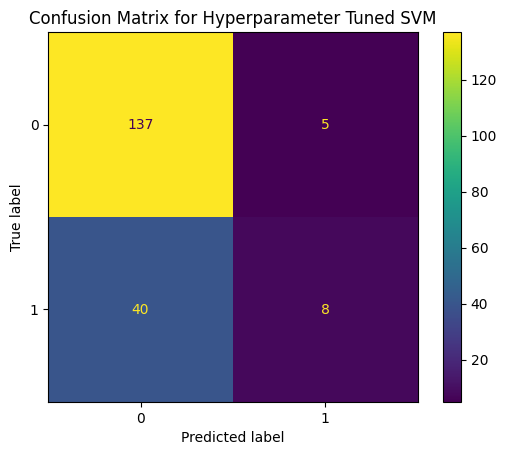

In [26]:
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Hyperparameter Tuned SVM')

In [27]:
accuracy = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
recall = recall_score(y_test, preds)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')

Accuracy: 0.7631578947368421
F1 Score: 0.26229508196721313
Recall Score: 0.16666666666666666
